<a href="https://colab.research.google.com/github/Nniichha/229352-StatisticalLearning/blob/main/%E0%B8%AA%E0%B8%B3%E0%B9%80%E0%B8%99%E0%B8%B2%E0%B8%82%E0%B8%AD%E0%B8%87_Lab07_Boosted_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Boosted tree models on a simulated dataset

- [AdaBoostClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html#sklearn-ensemble-adaboostclassifier)
- [XGBClassifier documentation](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)
- [LGBMClassifier documentation](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm-lgbmclassifier)
- [GridSeachCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


- [Data](https://github.com/donlapark/ds352-labs/raw/main/Lab06-data.zip)


Perform GridSearchCV of the following three models on the provided training set (`X_train.csv` and `y_train.csv`)

1. Evaluate these models on the test set (`X_test.csv` and `y_test.csv`). **Keep searching (using cross-validation) until you find the model that achieves > 0.83 out-of-fold accuracy (use `GridSeachCV.best_score_` to obtain the out-of-fold accuracy)**

2. Report the test accuracy of your best model.

3. For each model, plot the feature importances

For `AdaBoostClassifier`, feature importances can be obtained by calling the `feature_importances_` attribute after fitting the model.

For `XGBClassifier` and `LGBMClassifier`, feature importances can be obtained using the library’s `plot_importance` function. Here is a minimal example in XGBoost:

In [19]:
from sklearn import datasets


iris = datasets.load_iris()
X = iris.data
y = iris.target

In [20]:
from sklearn.ensemble import AdaBoostClassifier


ab = AdaBoostClassifier()
ab.fit(X, y)
ab.feature_importances_

array([0.        , 0.05832968, 0.43044322, 0.5112271 ])

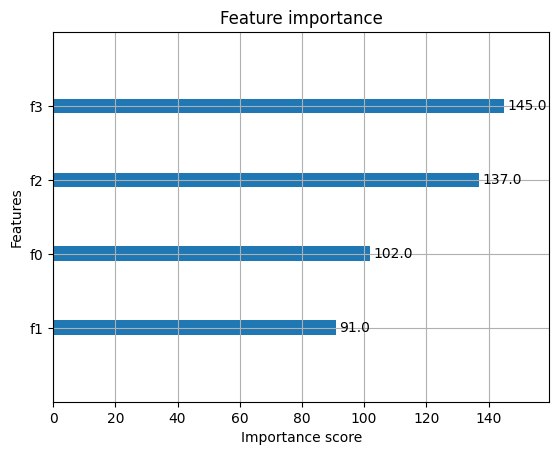

In [21]:
from xgboost import XGBClassifier, plot_importance


model = XGBClassifier()
model.fit(X, y)
plot_importance(model);

In [22]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


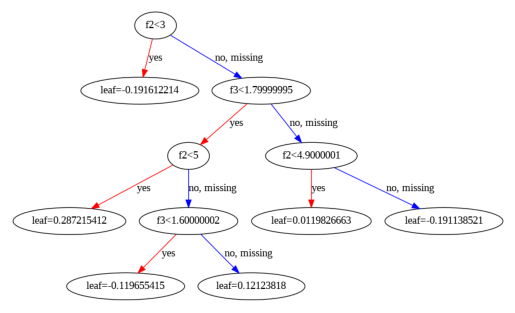

In [23]:
from xgboost import plot_tree

plot_tree(model, num_trees=4);

In [24]:

from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(120, 4) (30, 4)


In [25]:
def progressive_gridsearch(name, model, grids, target=0.83):

    best = None
    best_score = -1

    for i, grid in enumerate(grids):

        gs = GridSearchCV(
            model,
            grid,
            scoring="accuracy",
            cv=cv,
            n_jobs=-1
        )

        gs.fit(X_train, y_train)

        print(f"{name} round {i+1}  best_score_ = {gs.best_score_:.4f}")

        if gs.best_score_ > best_score:
            best_score = gs.best_score_
            best = gs

        if gs.best_score_ > target:
            print(">>> reached target 0.83")
            return gs

    return best


In [26]:
#  AdaBoost
ab = AdaBoostClassifier(random_state=0)

ab_grids = [
    {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    },
    {
        "n_estimators": [200, 400, 800],
        "learning_rate": [0.005, 0.01, 0.05, 0.1]
    }
]


#  XGBoost
xgb = XGBClassifier(eval_metric="logloss")

xgb_grids = [
    {
        "n_estimators": [200, 400],
        "max_depth": [3,5],
        "learning_rate": [0.05, 0.1]
    },
    {
        "n_estimators": [400,800],
        "max_depth": [3,4,6],
        "learning_rate": [0.01,0.05,0.1]
    }
]


# LightGBM
lgbm = LGBMClassifier()

lgbm_grids = [
    {
        "n_estimators":[300,600],
        "learning_rate":[0.03,0.1]
    },
    {
        "n_estimators":[600,1200],
        "learning_rate":[0.01,0.05,0.1]
    }
]


In [27]:
ab_gs   = progressive_gridsearch("AdaBoost", ab, ab_grids)
xgb_gs  = progressive_gridsearch("XGB", xgb, xgb_grids)
lgbm_gs = progressive_gridsearch("LGBM", lgbm, lgbm_grids)

models = [
    ("AdaBoost", ab_gs),
    ("XGB", xgb_gs),
    ("LGBM", lgbm_gs)
]

best_name, best_gs = max(models, key=lambda x: x[1].best_score_)

print("Best model =", best_name)
print("OOF accuracy =", best_gs.best_score_)


AdaBoost round 1  best_score_ = 0.9750
>>> reached target 0.83
XGB round 1  best_score_ = 0.9500
>>> reached target 0.83
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [28]:
best_model = best_gs.best_estimator_

y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy =", test_acc)


Test Accuracy = 0.9666666666666667


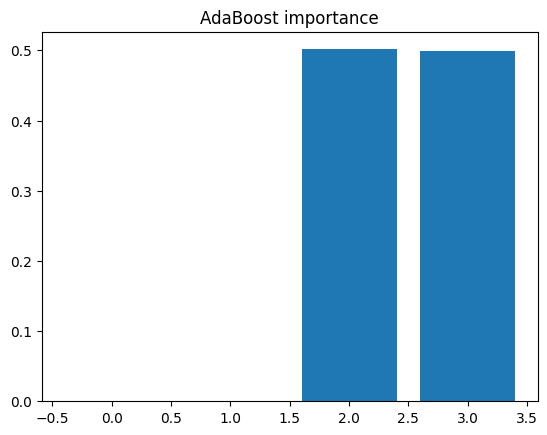

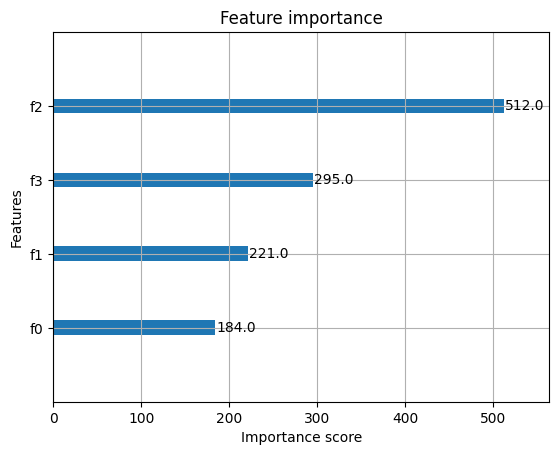

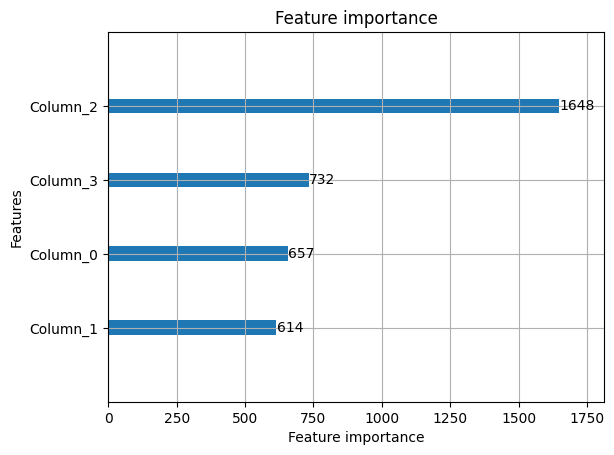

In [29]:
# AdaBoost
plt.bar(range(len(ab_gs.best_estimator_.feature_importances_)),
        ab_gs.best_estimator_.feature_importances_)
plt.title("AdaBoost importance")
plt.show()


# XGB
xgb_plot_importance(xgb_gs.best_estimator_)
plt.show()


# LGBM
lgbm_plot_importance(lgbm_gs.best_estimator_)
plt.show()
